<a href="https://colab.research.google.com/github/parthpatel182003/Sentinel-2/blob/main/notebooks/02_preprocess_phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 Preprocess And Phase 1 Image Processing

This notebook prepares the downloaded bands and builds the classical water detection baseline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

REPO_PATH = "/content/WaterDetectionProjectRepo"

if not os.path.exists(REPO_PATH):
    !git clone https://github.com/parthpatel182003/Sentinel-2.git {REPO_PATH}

%cd {REPO_PATH}

/content/WaterDetectionProjectRepo


In [17]:
import sys
from pathlib import Path

REPO_ROOT = Path('/content/WaterDetectionProjectRepo')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.config import PROJECT_CONFIG, PATHS, ensure_project_dirs

ensure_project_dirs()

print("Config loaded")

Config loaded


In [67]:
%%writefile src/phase1_processing.py
import numpy as np
import rasterio
import cv2
import os
import matplotlib.pyplot as plt


def load_sentinel_image(path):
    with rasterio.open(path) as src:
        return {
            "blue": src.read(1),
            "green": src.read(2),
            "red": src.read(3),
            "nir": src.read(4),
            "swir": src.read(5),
            "meta": src.meta
        }


def compute_indices(bands):
    green = bands["green"].astype(np.float32)
    nir = bands["nir"].astype(np.float32)
    swir = bands["swir"].astype(np.float32)

    ndwi = (green - nir) / (green + nir + 1e-6)
    mndwi = (green - swir) / (green + swir + 1e-6)

    return ndwi, mndwi


def otsu_threshold(image):
    image = np.nan_to_num(image)

    image_norm = (image - image.min()) / (image.max() - image.min() + 1e-6)
    image_8bit = (image_norm * 255).astype(np.uint8)

    _, thresh = cv2.threshold(
        image_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Slight smoothing
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    return thresh


def remove_small_components(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    clean_mask = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]

        aspect_ratio = max(width, height) / (min(width, height) + 1e-6)

        # 🔥 FINAL FILTER
        if area > 300 and aspect_ratio < 5:
            clean_mask[labels == i] = 255

    return clean_mask


def remove_ocean_largest_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    largest_label = 1
    largest_area = 0

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > largest_area:
            largest_area = stats[i, cv2.CC_STAT_AREA]
            largest_label = i

    mask[labels == largest_label] = 0

    return mask


def save_mask(mask, meta, output_path):
    meta.update({
        "count": 1,
        "dtype": "uint8"
    })

    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(mask, 1)


def create_overlay(red, green, blue, mask, output_path):
    rgb = np.stack([red, green, blue], axis=-1)
    rgb = (rgb / (np.max(rgb) + 1e-6) * 255).astype(np.uint8)

    overlay = rgb.copy()
    overlay[mask == 255] = [255, 0, 0]

    plt.imshow(overlay)
    plt.axis("off")
    plt.savefig(output_path, bbox_inches="tight", pad_inches=0)
    plt.close()


def process_image(image_path, mask_dir, overlay_dir):
    name = os.path.basename(image_path).replace(".tif", "")

    bands = load_sentinel_image(image_path)
    _, mndwi = compute_indices(bands)

    mask = otsu_threshold(mndwi)

    mask = remove_small_components(mask)

    mask = remove_ocean_largest_component(mask)

    mask_path = os.path.join(mask_dir, f"{name}_water_mask_mndwi.tif")
    overlay_path = os.path.join(overlay_dir, f"{name}_water_overlay.png")

    save_mask(mask, bands["meta"], mask_path)
    create_overlay(
        bands["red"], bands["green"], bands["blue"],
        mask, overlay_path
    )

    water_pixels = np.sum(mask == 255)
    total_pixels = mask.size

    return {
        "image": name,
        "water_pixels": int(water_pixels),
        "water_ratio": float(water_pixels / total_pixels)
    }

Overwriting src/phase1_processing.py


In [68]:
!cat src/phase1_processing.py

import numpy as np
import rasterio
import cv2
import os
import matplotlib.pyplot as plt


def load_sentinel_image(path):
    with rasterio.open(path) as src:
        return {
            "blue": src.read(1),
            "green": src.read(2),
            "red": src.read(3),
            "nir": src.read(4),
            "swir": src.read(5),
            "meta": src.meta
        }


def compute_indices(bands):
    green = bands["green"].astype(np.float32)
    nir = bands["nir"].astype(np.float32)
    swir = bands["swir"].astype(np.float32)

    ndwi = (green - nir) / (green + nir + 1e-6)
    mndwi = (green - swir) / (green + swir + 1e-6)

    return ndwi, mndwi


def otsu_threshold(image):
    image = np.nan_to_num(image)

    image_norm = (image - image.min()) / (image.max() - image.min() + 1e-6)
    image_8bit = (image_norm * 255).astype(np.uint8)

    _, thresh = cv2.threshold(
        image_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Slight smoothing
    kernel = np.on

In [69]:
import sys
if "src.phase1_processing" in sys.modules:
    del sys.modules["src.phase1_processing"]

from src.phase1_processing import process_image

In [70]:
from src.phase1_processing import process_image

## To Implement

- read required bands for each scene
- align resolutions when needed
- compute NDWI and MNDWI
- apply thresholding
- refine masks with morphology
- save masks, overlays, and area summaries

In [71]:
import os
import pandas as pd

image_dir = "/content/drive/MyDrive/WaterDetectionProject_exports"
mask_dir = "/content/drive/MyDrive/WaterDetectionProject/masks"
overlay_dir = "/content/drive/MyDrive/WaterDetectionProject/overlays"

os.makedirs(mask_dir, exist_ok=True)
os.makedirs(overlay_dir, exist_ok=True)

In [72]:
results = []

files = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])

for file in files:
    path = os.path.join(image_dir, file)

    print(f"Processing: {file}")
    result = process_image(path, mask_dir, overlay_dir)
    results.append(result)

Processing: kuttanad_kerala_scene_1.tif
Processing: kuttanad_kerala_scene_2.tif
Processing: kuttanad_kerala_scene_3.tif
Processing: kuttanad_s2_first_image.tif


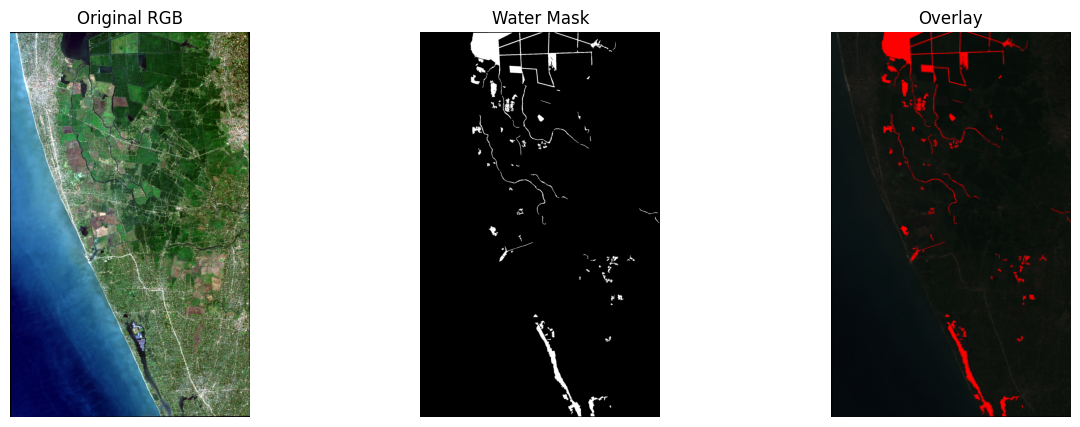

In [73]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os

# Pick first processed file
sample_file = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])[0]

image_path = os.path.join(image_dir, sample_file)
mask_path = os.path.join(mask_dir, sample_file.replace(".tif", "_water_mask_mndwi.tif"))
overlay_path = os.path.join(overlay_dir, sample_file.replace(".tif", "_water_overlay.png"))

# Load RGB
with rasterio.open(image_path) as src:
    red = src.read(3).astype(np.float32)
    green = src.read(2).astype(np.float32)
    blue = src.read(1).astype(np.float32)

def normalize(b):
    p2, p98 = np.percentile(b, (2, 98))
    b = np.clip(b, p2, p98)
    return (b - p2) / (p98 - p2 + 1e-6)

rgb = np.stack([normalize(red), normalize(green), normalize(blue)], axis=-1)

# Load mask
with rasterio.open(mask_path) as src:
    mask = src.read(1)

# Load overlay
overlay = plt.imread(overlay_path)

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Water Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()